In [2]:
import gymnasium as gym
import ale_py

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyvirtualdisplay import Display

%matplotlib inline

In [3]:
env_name = "ALE/MsPacman-v5"

env = gym.make(env_name, render_mode="rgb_array")

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


### Exploring the environment

In [ ]:
env.action_space

In [ ]:
list(range(env.action_space.n))

In [ ]:
env.observation_space

So the observation space is 210x160 3-channel array with values between 0-255 in RGB array mode

In [ ]:
obs, info = env.reset()

In [ ]:
info

In [ ]:
plt.imshow(obs)

### Reshaping the observation

4 0.0 False False {'lives': 2, 'episode_frame_number': 828, 'frame_number': 2204}


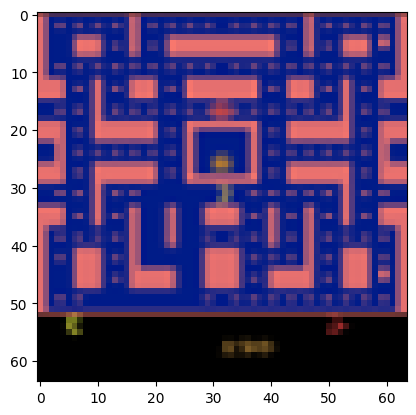

In [556]:
from PIL import Image
env_64 = gym.wrappers.ResizeObservation(env, (84, 65))

# obs, info  = env_64.reset()

sample_act = env.action_space.sample()
obs, reward, truncated, terminated, info = env_64.step(sample_act)
print(sample_act, reward, truncated, terminated, info)

obs = Image.fromarray(obs)
plt.imshow(obs.resize((64, 64)))

### Recording and Evaluating rollouts

In [28]:
num_eval_eps = 5

env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(
    env_rec, buffer_length=num_eval_eps
)

rewards_hist = []

/home/utkarsh/active_projects/world-models/.venv/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/utkarsh/active_projects/world-models/videos/examples folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [29]:
for ep_num in range(num_eval_eps):
    obs, info = env_rec.reset()
    ep_reward = 0
    step_count = 0
    
    while True:
        action = env_rec.action_space.sample()
        obs, reward, terminated, truncated, info= env_rec.step(action)
        
        ep_reward += float(reward)
        step_count += 1
        
        if (terminated or truncated): break
    
    print(f"Episode {ep_num + 1}: {step_count} steps, reward = {ep_reward}")

env_rec.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env_rec.time_queue)}')
print(f'Episode rewards: {list(env_rec.return_queue)}')
print(f'Episode lengths: {list(env_rec.length_queue)}')

# Calculate some useful metrics
avg_reward = np.mean(env_rec.return_queue)
avg_length = np.sum(env_rec.length_queue)
std_reward = np.std(env_rec.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env_rec.return_queue if r > 0) / len(env_rec.return_queue):.1%}')


Episode 1: 535 steps, reward = 220.0
Episode 2: 523 steps, reward = 310.0
Episode 3: 503 steps, reward = 330.0
Episode 4: 721 steps, reward = 270.0
Episode 5: 545 steps, reward = 330.0

Evaluation Summary:
Episode durations: [0.860238, 0.51254, 0.42188, 0.655216, 0.526021]
Episode rewards: [220.0, 310.0, 330.0, 270.0, 330.0]
Episode lengths: [535, 523, 503, 721, 545]

Average reward: 292.00 ± 42.14
Average episode length: 2827.0 steps
Success rate: 100.0%


### Checking `env.reset()` multiple times

In [4]:
env = gym.make(env_name, render_mode="rgb_array")

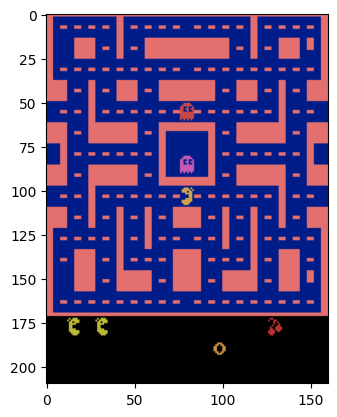

In [27]:
obs, info = env.reset()
plt.imshow(obs)